# BNS Dataset Sanity Check — 4096 Hz / 5 s
Verify signal quality, PSD, Q-spectrogram, and BNSReg-style downsampling across train / val / test splits.

In [ ]:
import os, random
import h5py
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import yaml
from gwpy.timeseries import TimeSeries

%matplotlib inline

# ── Paths ─────────────────────────────────────────────────────────────────────
DATA_DIR = "/n/holystore01/LABS/iaifi_lab/Lab/kyoon/DATA/checks/bns_snr_8_50_uniform_4096Hz_100K_5s"
TRAIN_H5 = os.path.join(DATA_DIR, "train", "sig_combined_train.h5")
VAL_H5   = os.path.join(DATA_DIR, "val",   "sig_combined_val.h5")
TEST_H5  = os.path.join(DATA_DIR, "test",  "sig_combined_test.h5")

TRAIN_CFG = os.path.join(DATA_DIR, "BNS_SNR8-50_TRAIN_VAL_4096Hz_BNS_uniform_spin_rejection_sampling.yaml")
TEST_CFG  = os.path.join(DATA_DIR, "BNS_SNR8-50_TEST_4096Hz_BNS_uniform_spin.yaml")

# ── Signal properties ─────────────────────────────────────────────────────────
SAMPLE_RATE      = 4096          # Hz — native rate stored in h5
DURATION_S       = 5.0           # seconds per event
COALESCENCE_S    = 4.0           # coalescence time from start (right_pad = 1 s)
SHOW_END_S       = 5.0           # plot / PSD window: 0 → SHOW_END_S

# BNSReg-style downsampling target (must evenly divide SAMPLE_RATE)
# 512 Hz gives Nyquist 256 Hz, allowing q_transform to reach ~240 Hz on 4 s segments.
# 256 Hz cuts off at ~80 Hz due to gwpy tile-length constraints on short segments.
DOWNSAMPLE_TARGET_HZ = 256       # 4096 / 256 = factor 16

N_EVENTS  = 3                    # events to plot per split
SEED      = 42

IFO_COLORS = {'H1': '#4ba6fb', 'L1': '#ff8c00'}
IFO_NAMES  = ['H1', 'L1']

SPLITS = [
    ('train', TRAIN_H5, TRAIN_CFG),
    ('val',   VAL_H5,   TRAIN_CFG),   # val uses same generation config as train
    ('test',  TEST_H5,  TEST_CFG),
]

print(f"Native rate : {SAMPLE_RATE} Hz")
print(f"Target rate : {DOWNSAMPLE_TARGET_HZ} Hz (factor {SAMPLE_RATE // DOWNSAMPLE_TARGET_HZ}x)")
print(f"Show window : 0 – {SHOW_END_S} s  ({int(SHOW_END_S * SAMPLE_RATE)} samples)")

Native rate : 4096 Hz
Target rate : 256 Hz (factor 16x)
Show window : 0 – 5.0 s  (20480 samples)


In [ ]:
# ── Helper functions ──────────────────────────────────────────────────────────

def make_ts(arr, fs, t0=0.0):
    """Wrap a 1-D numpy array as a gwpy TimeSeries."""
    return TimeSeries(arr.astype(float), sample_rate=fs, t0=t0)


def bnsreg_downsample(data_2d, fs, new_fs):
    """Exact BNSReg regression-loader downsampling (base_dataset._read_strain).
    data_2d : (n_channels, n_samples)
    Returns  : (n_channels, n_samples_new)
    """
    return np.array([
        TimeSeries(data_2d[c], sample_rate=fs).resample(new_fs).value
        for c in range(data_2d.shape[0])
    ])


def slice_to_window(data_2d, fs, t_start, t_end):
    """Return data_2d[:, i_start:i_end] corresponding to [t_start, t_end] seconds."""
    i0 = int(round(t_start * fs))
    i1 = int(round(t_end   * fs))
    return data_2d[:, i0:i1]


def load_events(h5_path, indices):
    """Load whitened_injected, whitened_signal, and scalar params for given indices."""
    with h5py.File(h5_path, 'r') as f:
        injected = f['whitened_injected'][indices]   # (n, 2, T)
        signal   = f['whitened_signal'][indices]
        bkg      = f['whitened_bkg'][indices]
        snr      = f['snr'][indices]
        m1       = f['mass_1'][indices]
        m2       = f['mass_2'][indices]
        dist     = f['distance'][indices]
        chirp    = f['chirp_mass'][indices]
    params = dict(snr=snr, mass_1=m1, mass_2=m2, distance=dist, chirp_mass=chirp)
    return injected, signal, bkg, params


print("Helpers defined.")

Helpers defined.


In [ ]:
# ── Plotting functions ────────────────────────────────────────────────────────
from matplotlib.colors import LogNorm

def plot_timeseries(ax, data_2d, fs, label_prefix, snr_val, t_end):
    t = np.arange(data_2d.shape[1]) / fs
    t_rel = t - COALESCENCE_S
    for ci, ifo in enumerate(IFO_NAMES):
        ax.plot(t_rel, data_2d[ci], color=IFO_COLORS[ifo], lw=0.7, alpha=0.9, label=ifo)
    ax.axvline(0.0, color='gray', lw=0.8, ls='--', alpha=0.6, label='coalescence')
    ax.set_xlim(-COALESCENCE_S, t_end - COALESCENCE_S)
    ax.set_xticks(np.arange(-COALESCENCE_S, 1, 1))
    ax.set_ylabel('Whitened strain', fontsize=8)
    ax.set_title(f"{label_prefix} | SNR={snr_val:.1f}", fontsize=9)
    ax.legend(fontsize=8, loc='upper left')
    ax.grid(True, lw=0.3)


def plot_psd(ax, data_2d, fs, label):
    fftlen = max(1.0, data_2d.shape[1] / fs / 2)
    for ci, ifo in enumerate(IFO_NAMES):
        ts  = make_ts(data_2d[ci], fs)
        psd = ts.psd(fftlength=fftlen, overlap=fftlen / 2, method='median')
        ax.semilogy(psd.frequencies.value, psd.value,
                    color=IFO_COLORS[ifo], lw=0.9, alpha=0.9, label=ifo)
    ax.set_xlabel('Frequency [Hz]', fontsize=8)
    ax.set_ylabel('PSD [1/Hz]', fontsize=8)
    ax.set_title(f"{label} PSD", fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(True, which='both', lw=0.3)


def plot_qspectrogram(ax, data_1d, fs, ifo, snr_val, mc_val):
    """Q-transform with LogNorm so the dim early inspiral (2-3 s) is visible.

    PowerNorm was insufficient: Q-tile energy is tiny at early times (low freq,
    large tiles, power diluted across many bins) vs the bright merger. LogNorm
    compresses the full dynamic range logarithmically, pulling up both ends.

    vmin = 25th percentile  ≈ noise floor
    vmax = 99.5th percentile clips rare bright outliers at the merger peak
    """
    nyquist  = fs / 2
    fhi_plot = nyquist
    print('nyquist =', nyquist, 'Hz; fhi_plot =', fhi_plot, 'Hz')

    ts    = make_ts(data_1d, fs)
    qgram = ts.q_transform(frange=(20, fhi_plot),
                            qrange=(64, 128),
                            outseg=(0, SHOW_END_S),
                            logf=True,
                            whiten=False)

    energies = qgram.value                      # (n_time, n_freq)
    times    = qgram.times.value                # centres of time bins
    freqs    = qgram.frequencies.value          # centres of freq bins (log-spaced)

    # bin edges for pcolormesh
    dt      = qgram.dt.value
    t_edges = np.append(times - dt / 2, times[-1] + dt / 2)
    t_edges = t_edges - COALESCENCE_S

    log_f    = np.log(freqs)
    dlf      = np.diff(log_f)
    f_edges  = np.exp(np.concatenate([
        [log_f[0]  - dlf[0]  / 2],
        (log_f[:-1] + log_f[1:]) / 2,
        [log_f[-1] + dlf[-1] / 2],
    ]))

    vmin = 1
    vmax = np.percentile(energies, 99.5)
    norm = LogNorm(vmin=vmin, vmax=vmax)

    img = ax.pcolormesh(t_edges, f_edges, energies.T,
                        cmap='YlOrRd', norm=norm, shading='flat')
    plt.colorbar(img, ax=ax, label='Norm. energy (log scale)', pad=0.02)
    ax.set_yscale('log')
    ax.set_ylim(freqs[0], fhi_plot)
    ax.set_xlim(-COALESCENCE_S, SHOW_END_S - COALESCENCE_S)
    ax.set_xticks(np.arange(-COALESCENCE_S, SHOW_END_S - COALESCENCE_S + 1, 1))
    ax.set_xlabel('time until merger [s]', fontsize=8)
    ax.set_ylabel('Frequency [Hz]', fontsize=8)
    ax.set_title(f"Q-transform {ifo} | Mc={mc_val:.3f} M☉ | SNR={snr_val:.1f}", fontsize=9)
    ax.axvline(0.0, color='black', lw=1.0, ls='--', alpha=0.8, label='coalescence')
    ax.legend(fontsize=7)


print("Plot functions defined.")

Plot functions defined.


In [ ]:
# ── Main per-split sanity check ───────────────────────────────────────────────

def sanity_check_split(split_name, h5_path, cfg_path, seed=SEED):
    print(f"\n{'='*60}")
    print(f"  Split : {split_name}")
    print(f"  File  : {h5_path}")
    print(f"{'='*60}")

    with h5py.File(h5_path, 'r') as f:
        n_total, n_ch, n_samp = f['whitened_injected'].shape
    print(f"  Events : {n_total}   Channels : {n_ch}   Samples : {n_samp}  "
          f"({n_samp / SAMPLE_RATE:.2f} s @ {SAMPLE_RATE} Hz)")

    rng     = random.Random(seed)
    indices = sorted(rng.sample(range(n_total), N_EVENTS))
    print(f"  Plotting event indices : {indices}")

    injected, signal, bkg, params = load_events(h5_path, indices)
    snrs   = params['snr']
    masses = params['mass_1'], params['mass_2']
    chirps = params['chirp_mass']

    i_end_full = int(SHOW_END_S * SAMPLE_RATE)

    for ev_i in range(N_EVENTS):
        snr_v  = float(snrs[ev_i])
        m1, m2 = float(masses[0][ev_i]), float(masses[1][ev_i])
        mc     = float(chirps[ev_i])
        title  = (f"{split_name.upper()} event {indices[ev_i]}  "
                  f"m1={m1:.2f} m2={m2:.2f} Mc={mc:.3f} M☉  SNR={snr_v:.1f}")

        inj_win = injected[ev_i, :, :i_end_full]
        sig_win = signal[ev_i,   :, :i_end_full]

        # ── Time series ──────────────────────────────────────────────────────
        fig, axes = plt.subplots(1, 2, figsize=(14, 3.5), sharey=True)
        fig.suptitle(title, fontsize=10, y=1.01)
        plot_timeseries(axes[0], sig_win, SAMPLE_RATE,
                        'Whitened signal only', snr_v, SHOW_END_S)
        plot_timeseries(axes[1], inj_win, SAMPLE_RATE,
                        'Whitened injected (signal+bkg)', snr_v, SHOW_END_S)
        axes[0].set_xlabel('time until merger [s]', fontsize=9)
        axes[1].set_xlabel('time until merger [s]', fontsize=9)
        plt.tight_layout()
        plt.show()

        # ── PSD ──────────────────────────────────────────────────────────────
        fig, axes = plt.subplots(1, 2, figsize=(14, 3.5))
        plot_psd(axes[0], sig_win, SAMPLE_RATE, 'Whitened signal')
        plot_psd(axes[1], inj_win, SAMPLE_RATE, 'Whitened injected')
        plt.tight_layout()
        plt.show()

        # ── Q-spectrogram (native rate) ───────────────────────────────────────
        fig, axes = plt.subplots(1, 2, figsize=(14, 4))
        for ci, ifo in enumerate(IFO_NAMES):
            plot_qspectrogram(axes[ci], signal[ev_i, ci], SAMPLE_RATE, ifo, snr_v, mc)
        plt.suptitle(f"Q-spectrogram (native {SAMPLE_RATE} Hz) — {split_name} event {indices[ev_i]}",
                     fontsize=9, y=1.01)
        plt.tight_layout()
        plt.show()

        # ── BNSReg downsampled ────────────────────────────────────────────────
        ds_sig = bnsreg_downsample(signal[ev_i], SAMPLE_RATE, DOWNSAMPLE_TARGET_HZ)
        ds_inj = bnsreg_downsample(injected[ev_i], SAMPLE_RATE, DOWNSAMPLE_TARGET_HZ)

        ds_end     = int(SHOW_END_S * DOWNSAMPLE_TARGET_HZ)
        ds_sig_win = ds_sig[:, :ds_end]
        ds_inj_win = ds_inj[:, :ds_end]

        fig, axes = plt.subplots(1, 2, figsize=(14, 3.5), sharey=True)
        fig.suptitle(
            f"After BNSReg downsample {SAMPLE_RATE}→{DOWNSAMPLE_TARGET_HZ} Hz | "
            f"{split_name} event {indices[ev_i]} | SNR={snr_v:.1f}",
            fontsize=9, y=1.01
        )
        plot_timeseries(axes[0], ds_sig_win, DOWNSAMPLE_TARGET_HZ,
                        'Downsampled signal', snr_v, SHOW_END_S)
        plot_timeseries(axes[1], ds_inj_win, DOWNSAMPLE_TARGET_HZ,
                        'Downsampled injected', snr_v, SHOW_END_S)
        axes[0].set_xlabel('time until merger [s]', fontsize=9)
        axes[1].set_xlabel('time until merger [s]', fontsize=9)
        plt.tight_layout()
        plt.show()

        # Downsampled PSD
        fig, axes = plt.subplots(1, 2, figsize=(14, 3.5))
        plot_psd(axes[0], ds_sig_win, DOWNSAMPLE_TARGET_HZ,
                 f'Downsampled signal ({DOWNSAMPLE_TARGET_HZ} Hz)')
        plot_psd(axes[1], ds_inj_win, DOWNSAMPLE_TARGET_HZ,
                 f'Downsampled injected ({DOWNSAMPLE_TARGET_HZ} Hz)')
        plt.tight_layout()
        plt.show()

        # Downsampled Q-spectrogram
        fig, axes = plt.subplots(1, 2, figsize=(14, 4))
        for ci, ifo in enumerate(IFO_NAMES):
            plot_qspectrogram(axes[ci], ds_sig[ci], DOWNSAMPLE_TARGET_HZ, ifo, snr_v, mc)
        plt.suptitle(
            f"Q-spectrogram (downsampled {DOWNSAMPLE_TARGET_HZ} Hz) — "
            f"{split_name} event {indices[ev_i]}",
            fontsize=9, y=1.01
        )
        plt.tight_layout()
        plt.show()

        print("-" * 50)

print("sanity_check_split() defined.")

sanity_check_split() defined.


---
## Train split


  Split : train
  File  : /n/holystore01/LABS/iaifi_lab/Lab/kyoon/DATA/checks/bns_snr_8_50_uniform_4096Hz_100K_5s/train/sig_combined_train.h5
  Events : 80000   Channels : 2   Samples : 20480  (5.00 s @ 4096 Hz)
  Plotting event indices : [3278, 14592, 36048]


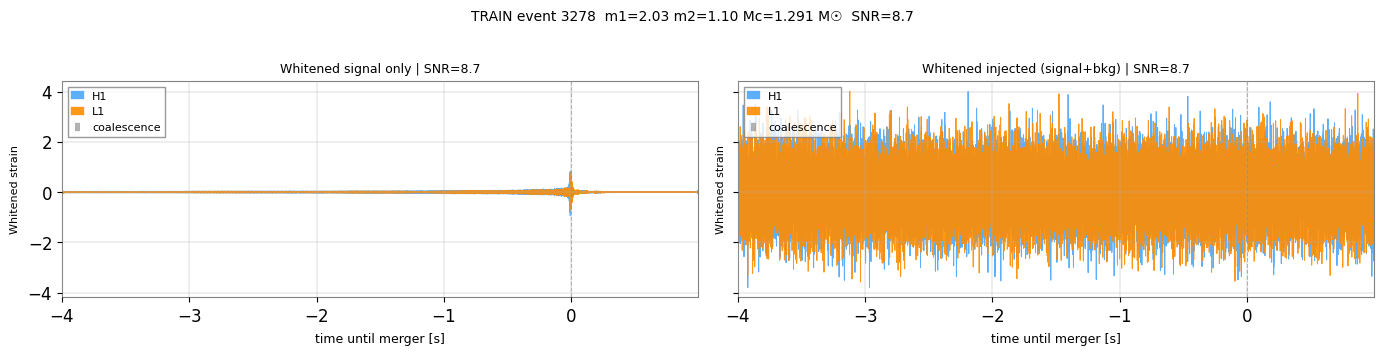

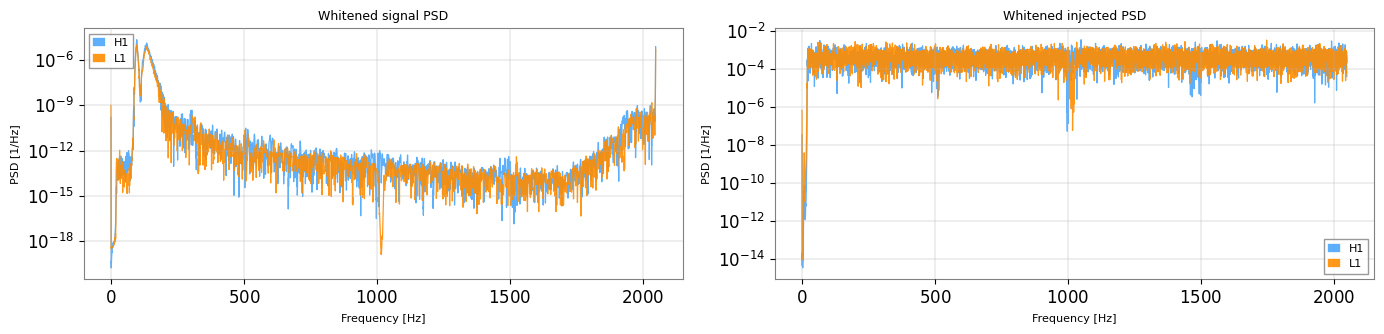

nyquist = 2048.0 Hz; fhi_plot = 1945.6 Hz
nyquist = 2048.0 Hz; fhi_plot = 1945.6 Hz


/n/home04/kyoon/miniforge3/envs/bns/lib/python3.12/site-packages/gwpy/signal/qtransform.py:124: UserWarning: upper frequency of 1945.60 is too high for the given Q range, resetting to 1908.16
  warnings.warn('upper frequency of %.2f is too high for the given '
/tmp/ipykernel_3527365/1266993351.py:60: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


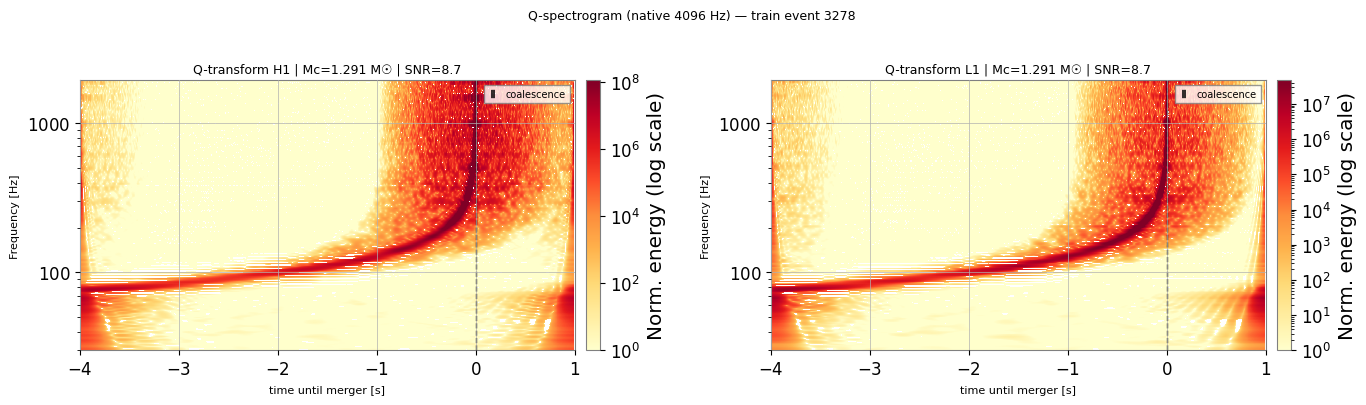

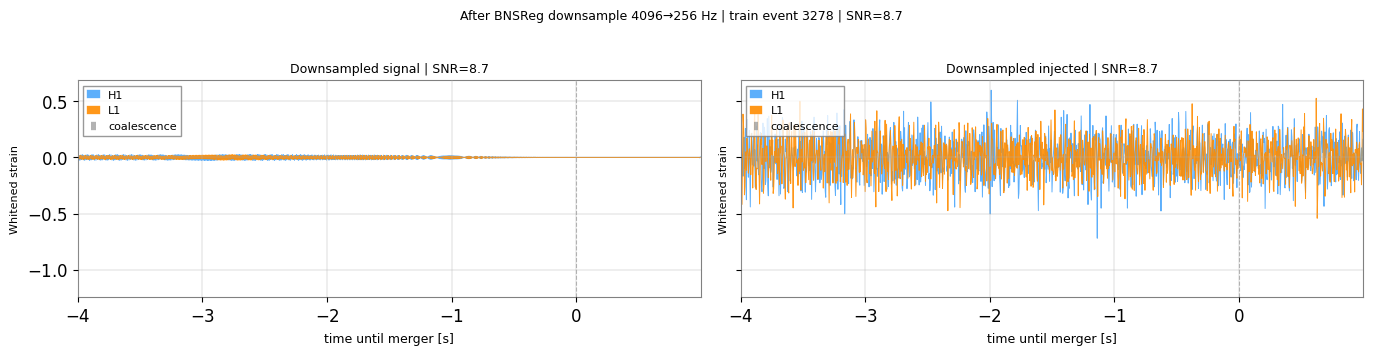

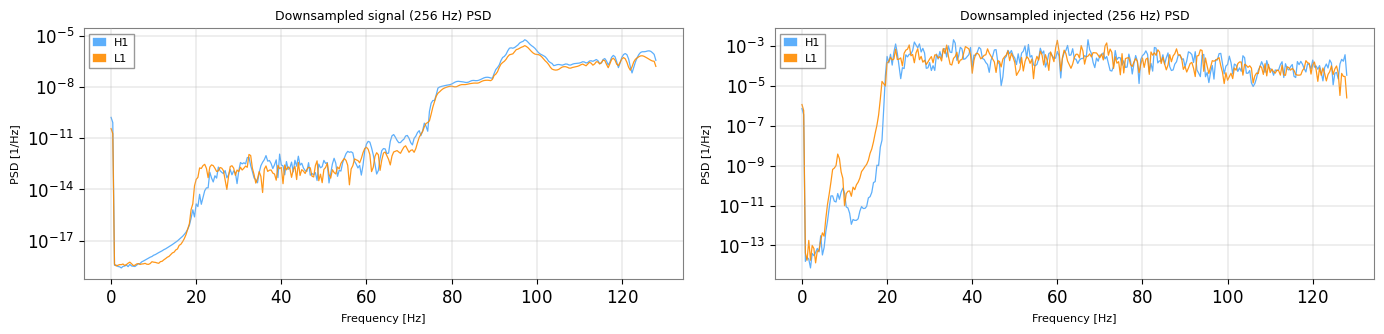

nyquist = 128.0 Hz; fhi_plot = 121.6 Hz
nyquist = 128.0 Hz; fhi_plot = 121.6 Hz


/n/home04/kyoon/miniforge3/envs/bns/lib/python3.12/site-packages/gwpy/signal/qtransform.py:124: UserWarning: upper frequency of 121.60 is too high for the given Q range, resetting to 119.26
  warnings.warn('upper frequency of %.2f is too high for the given '
/tmp/ipykernel_3527365/1266993351.py:104: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


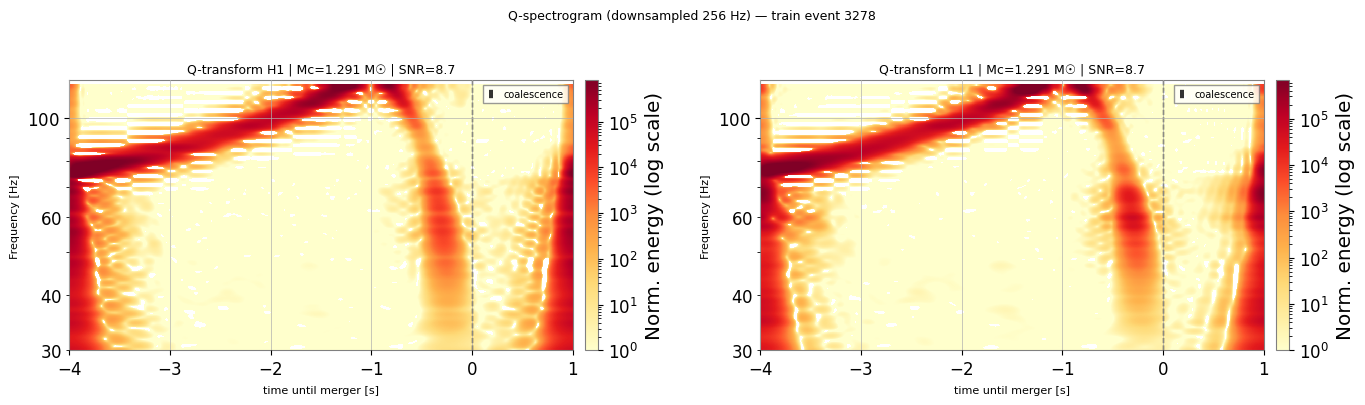

--------------------------------------------------


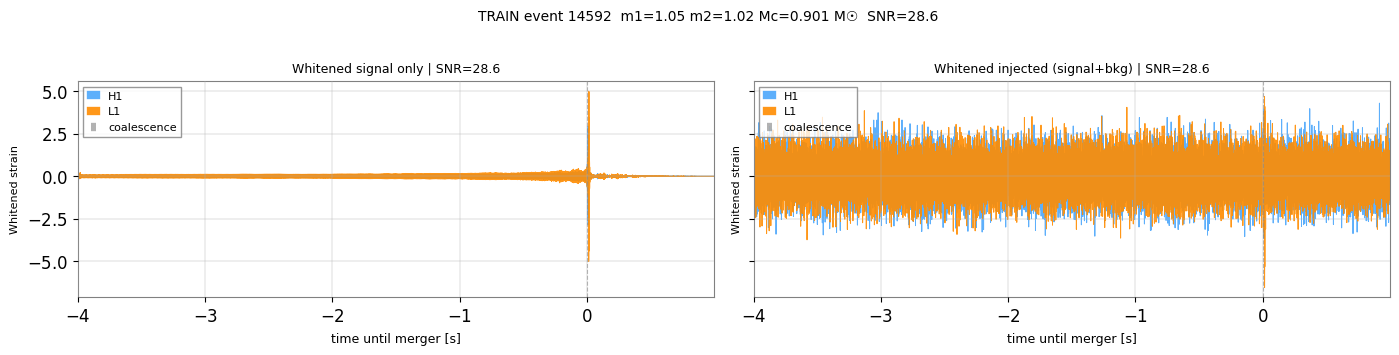

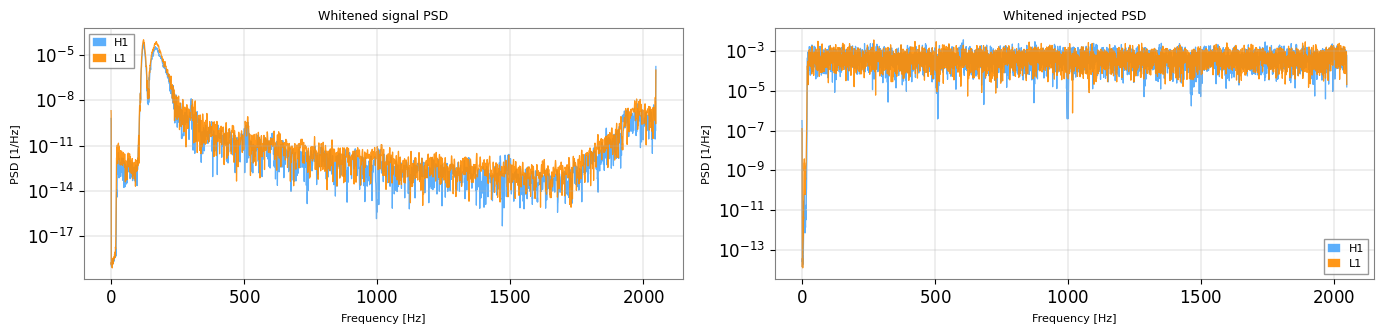

nyquist = 2048.0 Hz; fhi_plot = 1945.6 Hz
nyquist = 2048.0 Hz; fhi_plot = 1945.6 Hz


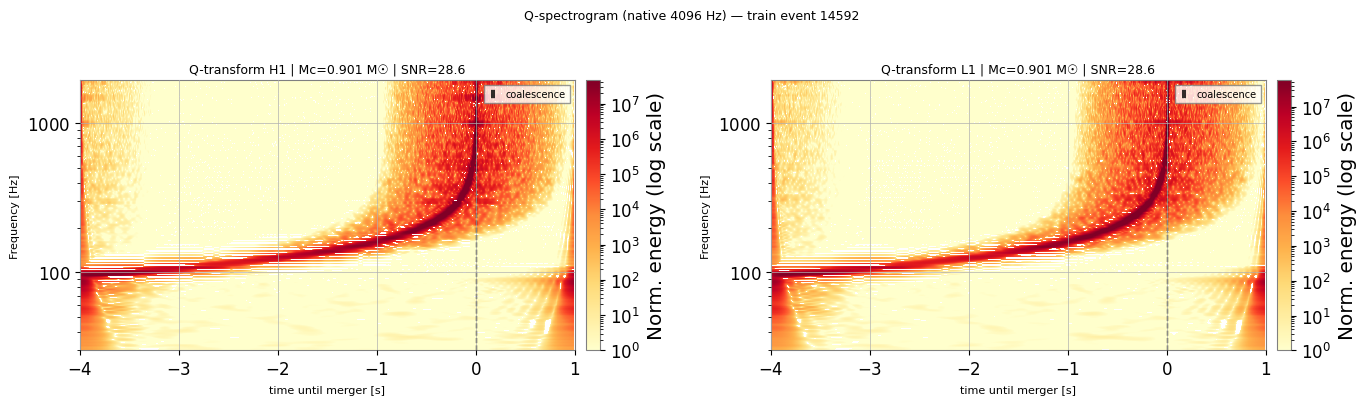

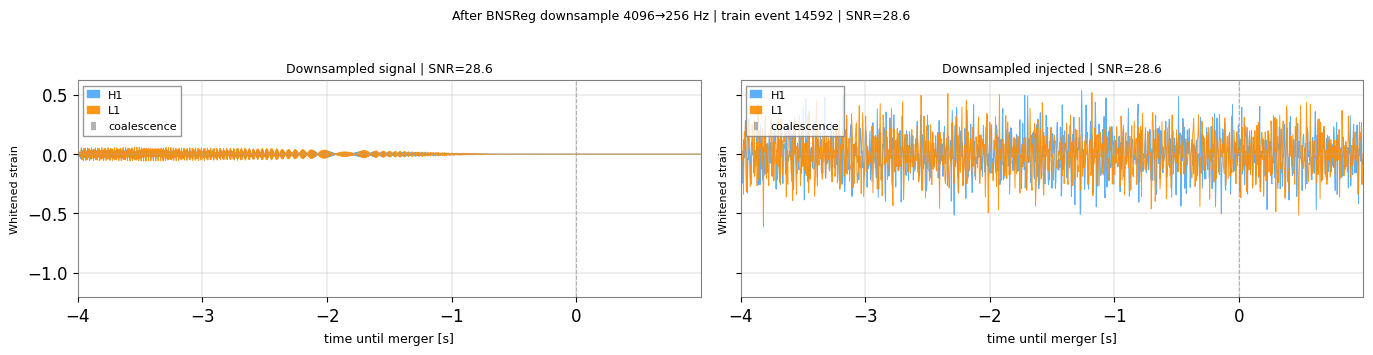

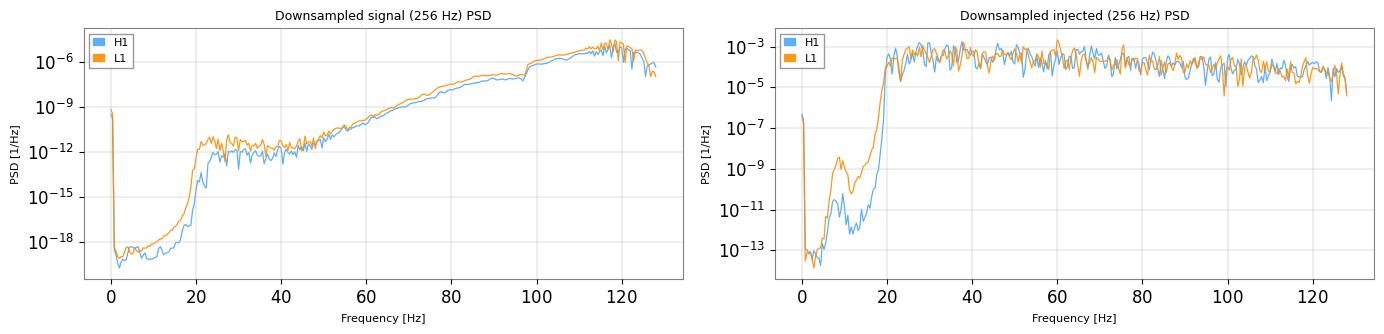

nyquist = 128.0 Hz; fhi_plot = 121.6 Hz
nyquist = 128.0 Hz; fhi_plot = 121.6 Hz


In [ ]:
sanity_check_split('train', TRAIN_H5, TRAIN_CFG)

---
## Val split


  Split : val
  File  : /n/holystore01/LABS/iaifi_lab/Lab/kyoon/DATA/checks/bns_snr_8_50_uniform_4096Hz_100K_5s/val/sig_combined_val.h5
  Events : 20000   Channels : 2   Samples : 20480  (5.00 s @ 4096 Hz)
  Plotting event indices : [1263, 4716, 9374]


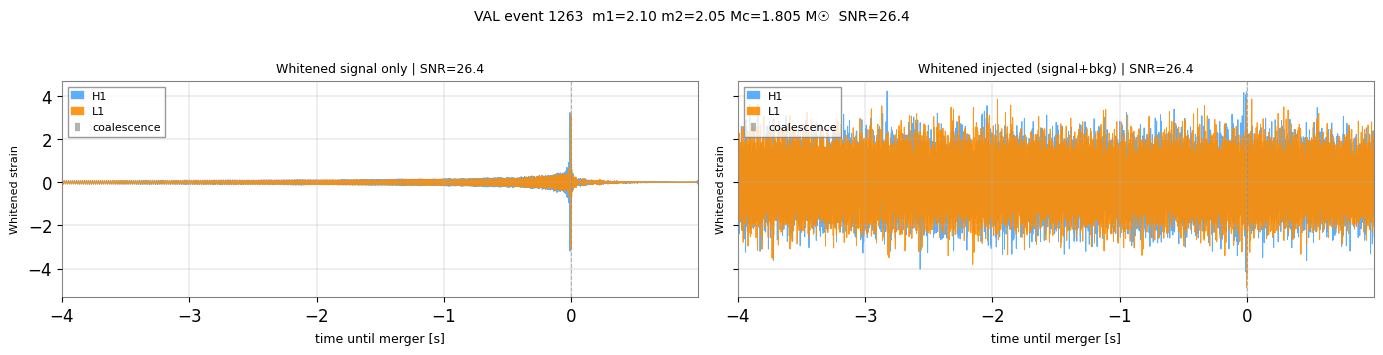

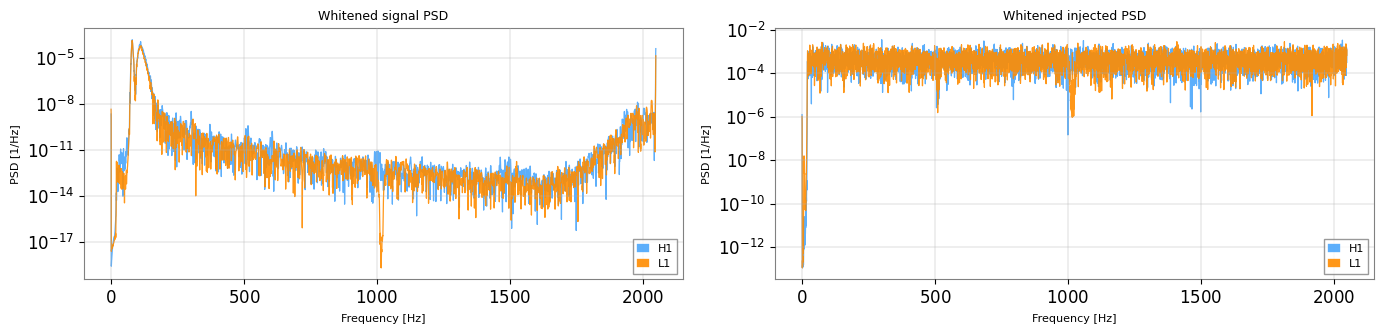

/tmp/ipykernel_3521704/1266993351.py:60: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


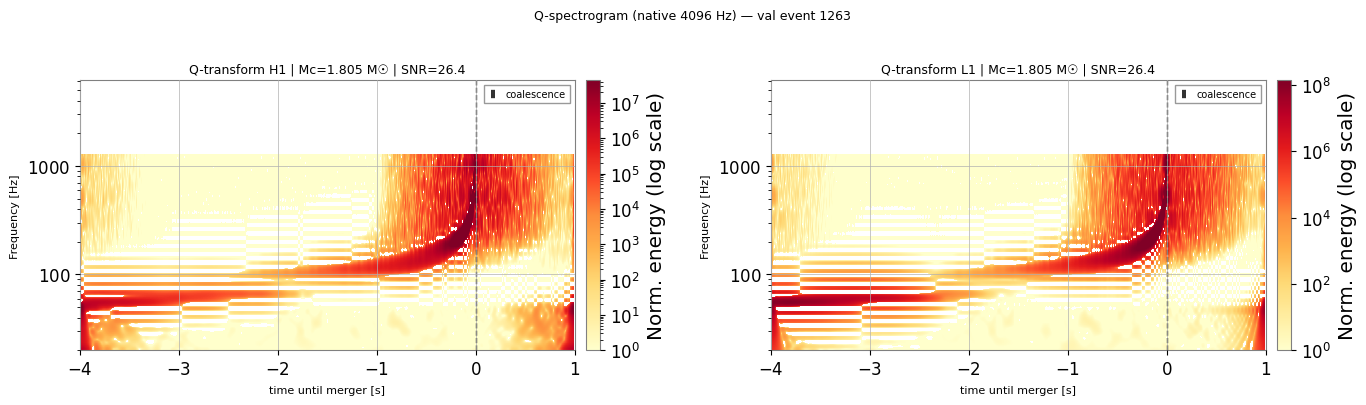

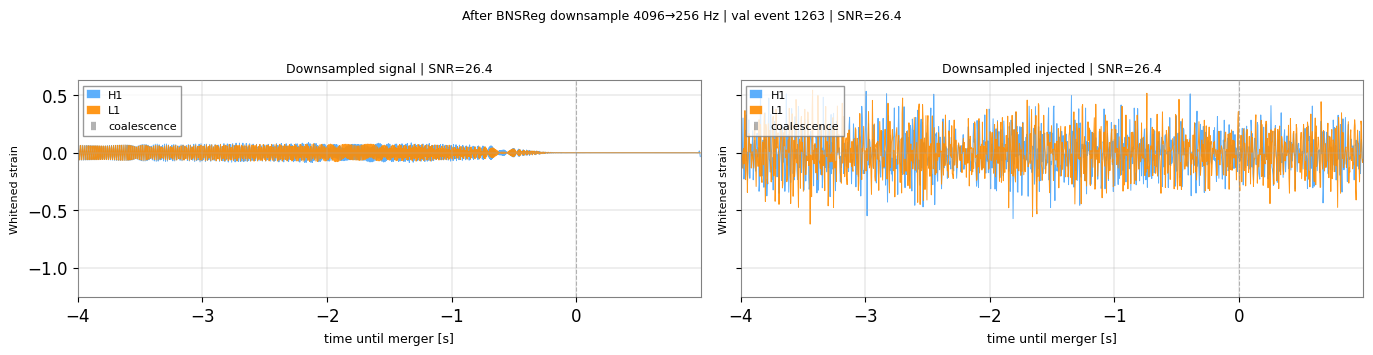

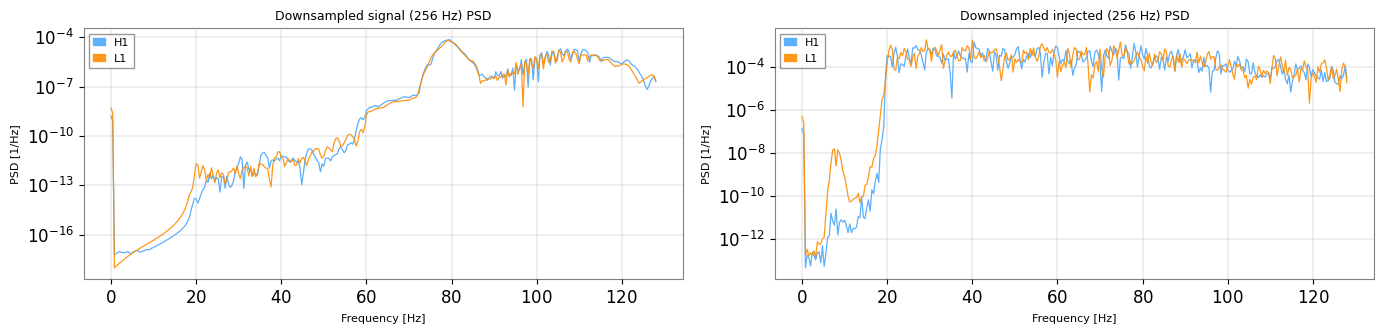

/tmp/ipykernel_3521704/1266993351.py:104: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


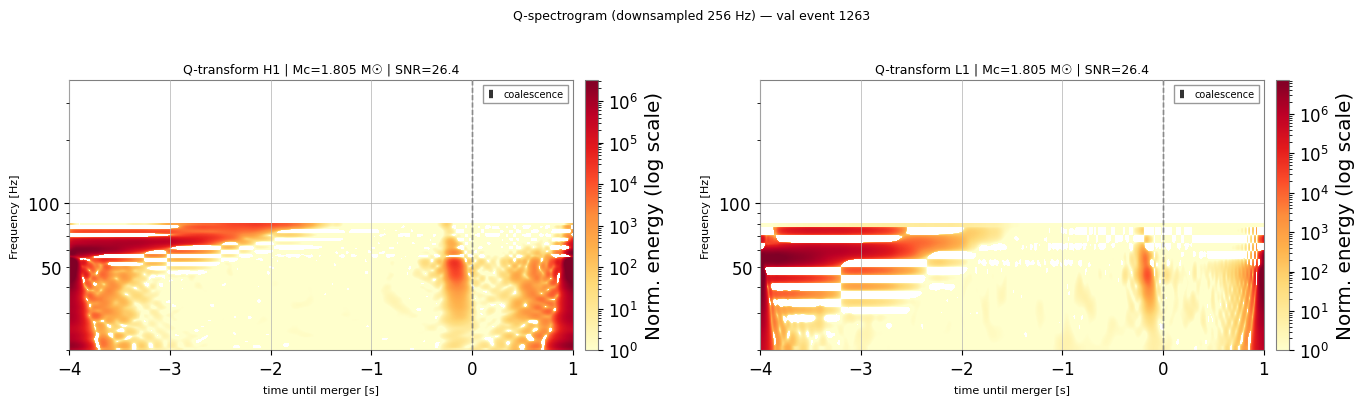

--------------------------------------------------


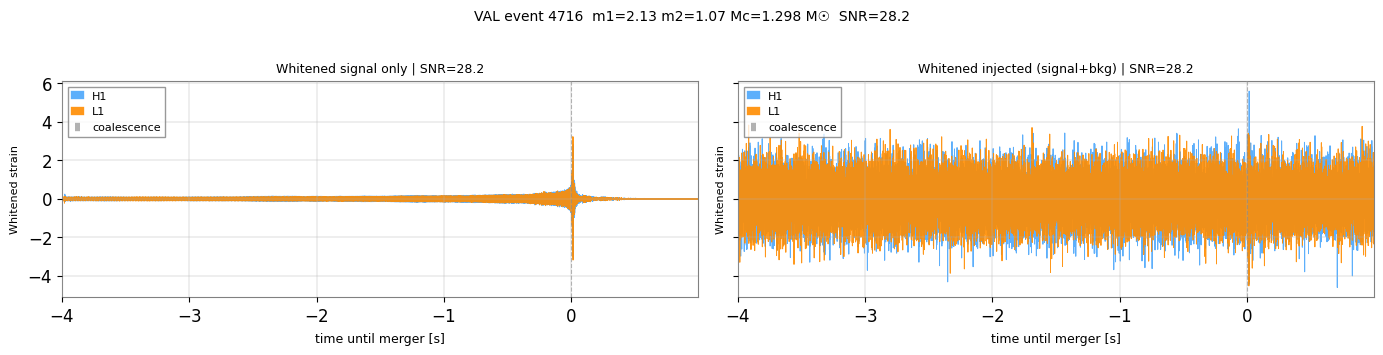

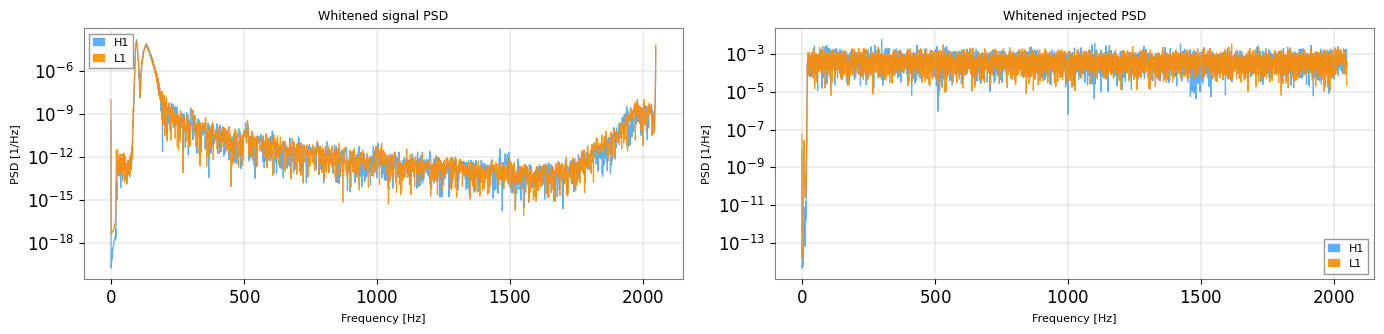

In [ ]:
sanity_check_split('val', VAL_H5, TRAIN_CFG, seed=SEED + 1)

---
## Test split


  Split : test
  File  : /n/holystore01/LABS/iaifi_lab/Lab/kyoon/DATA/checks/bns_snr_8_50_uniform_4096Hz_100K_5s/test/sig_combined_test.h5
  Events : 100000   Channels : 2   Samples : 20480  (5.00 s @ 4096 Hz)
  Plotting event indices : [53547, 68160, 71037]


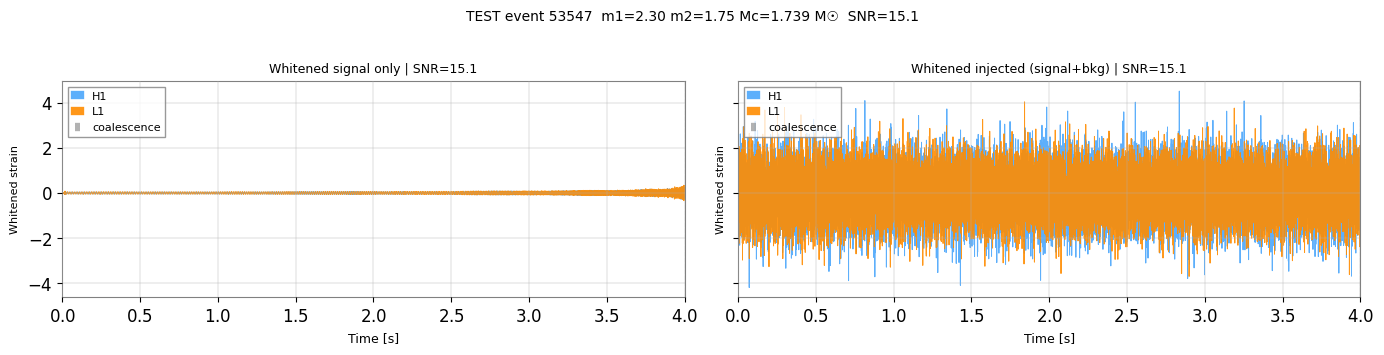

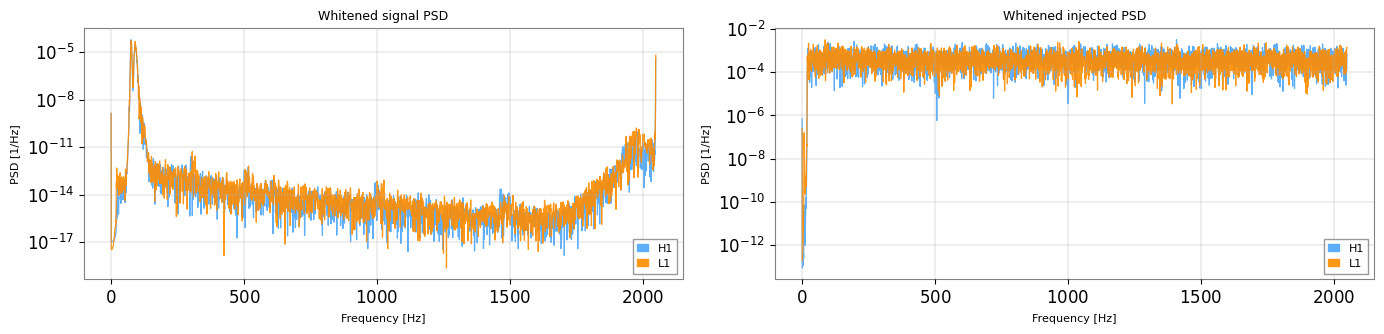

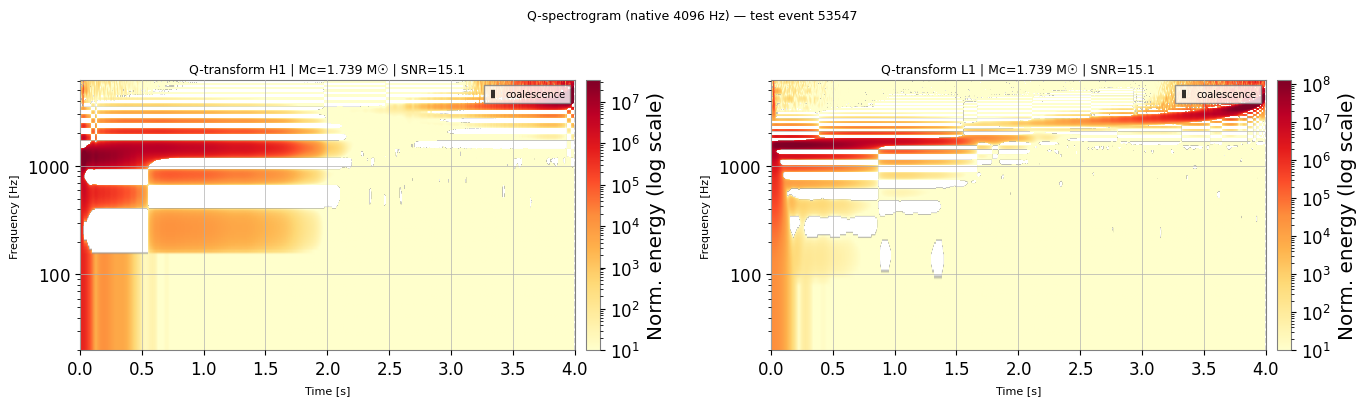

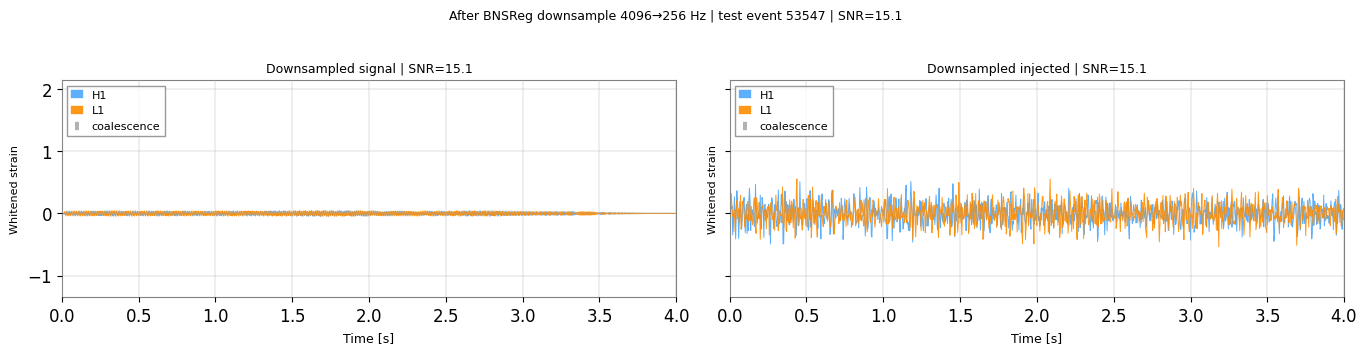

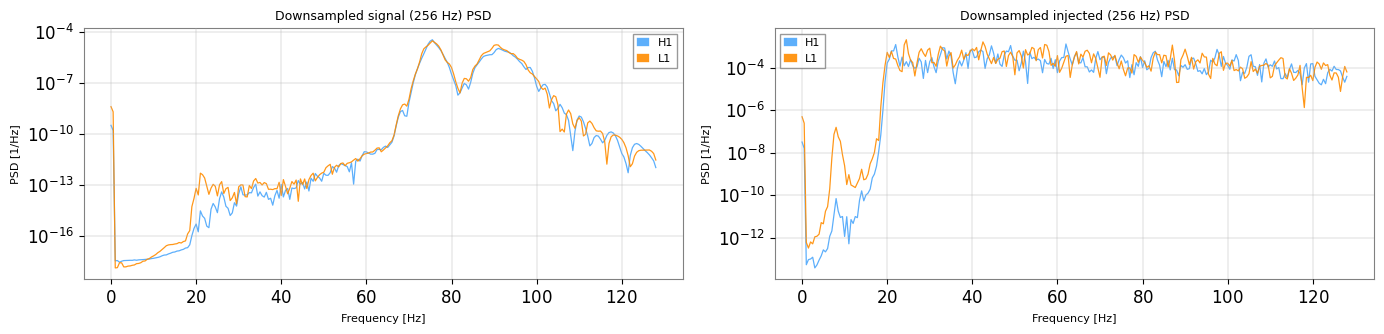

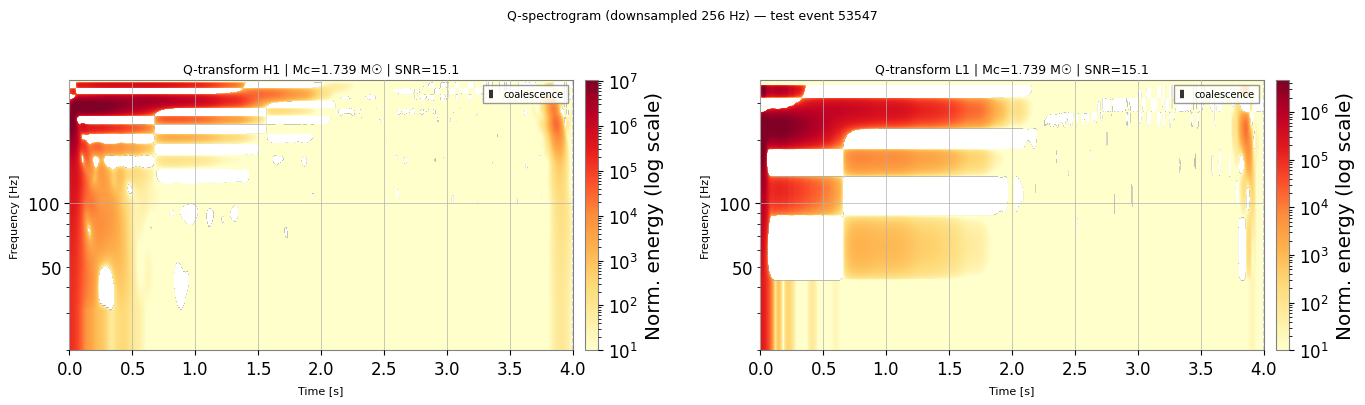

--------------------------------------------------


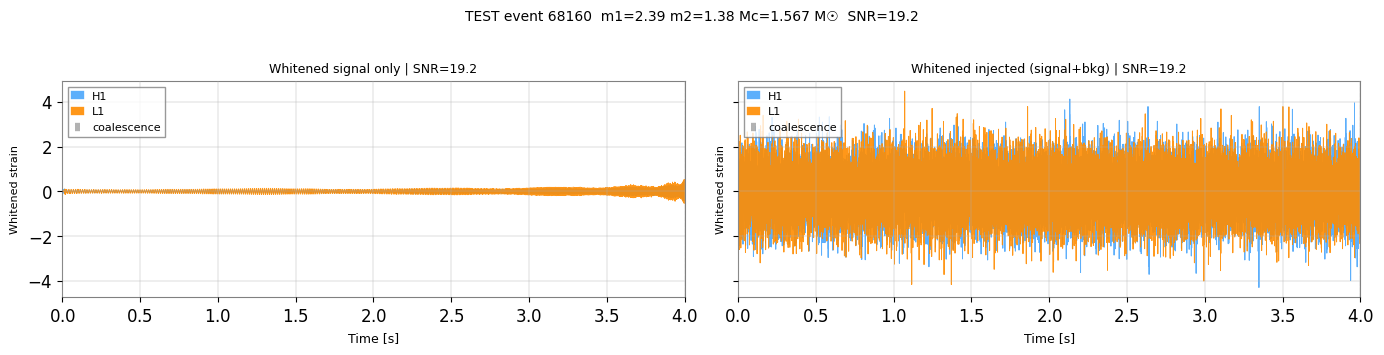

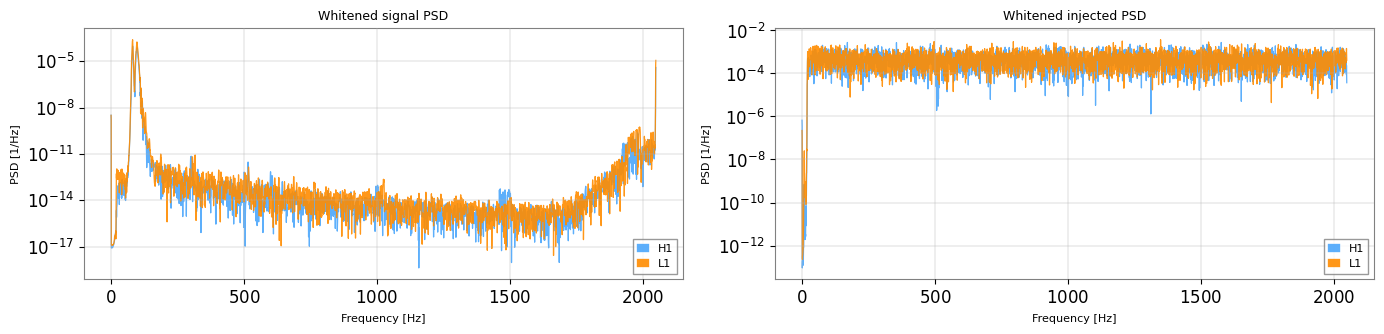

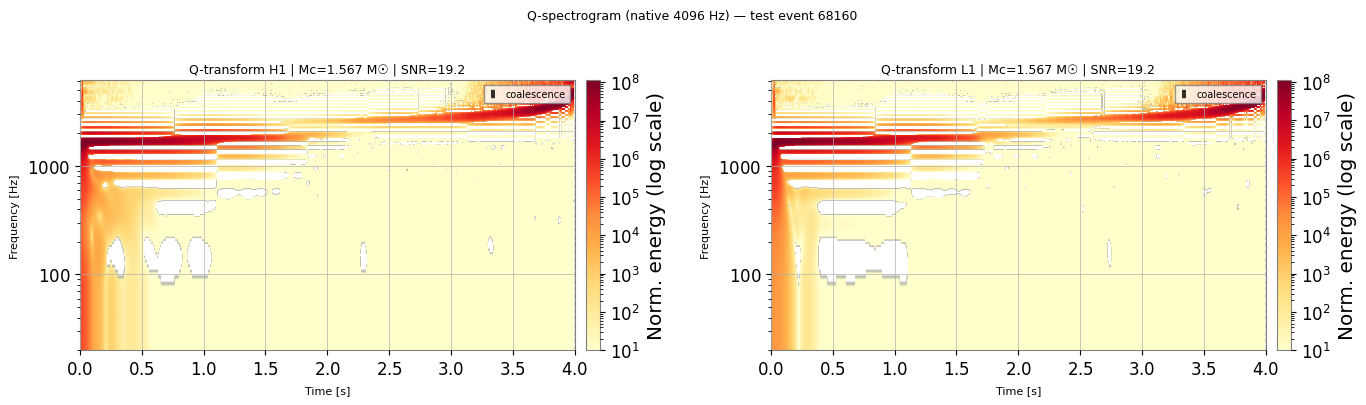

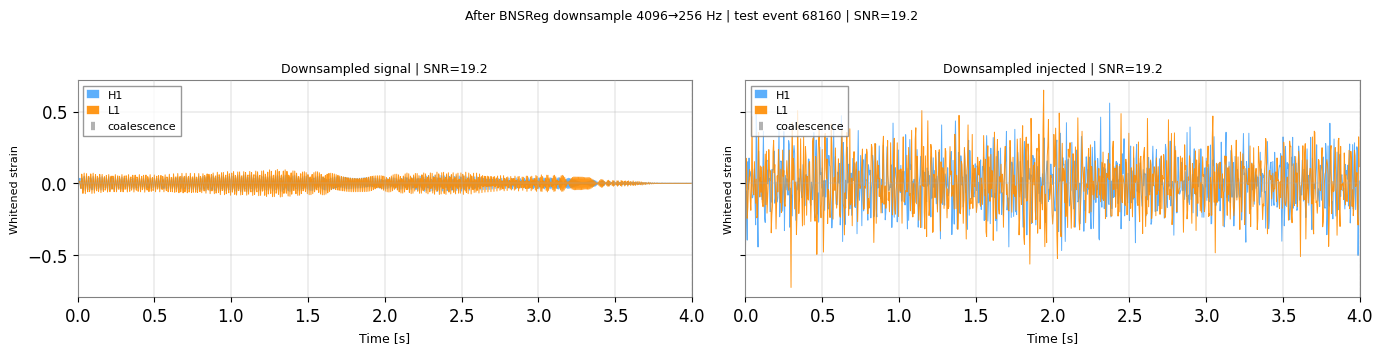

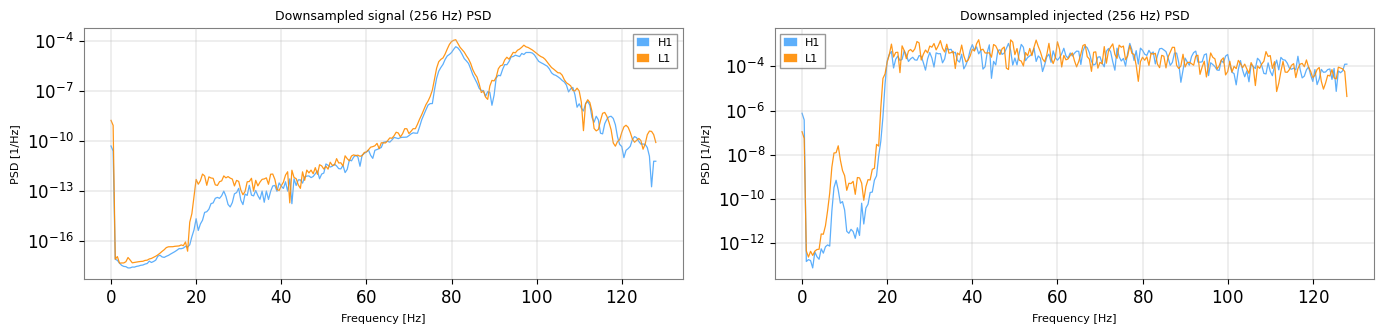

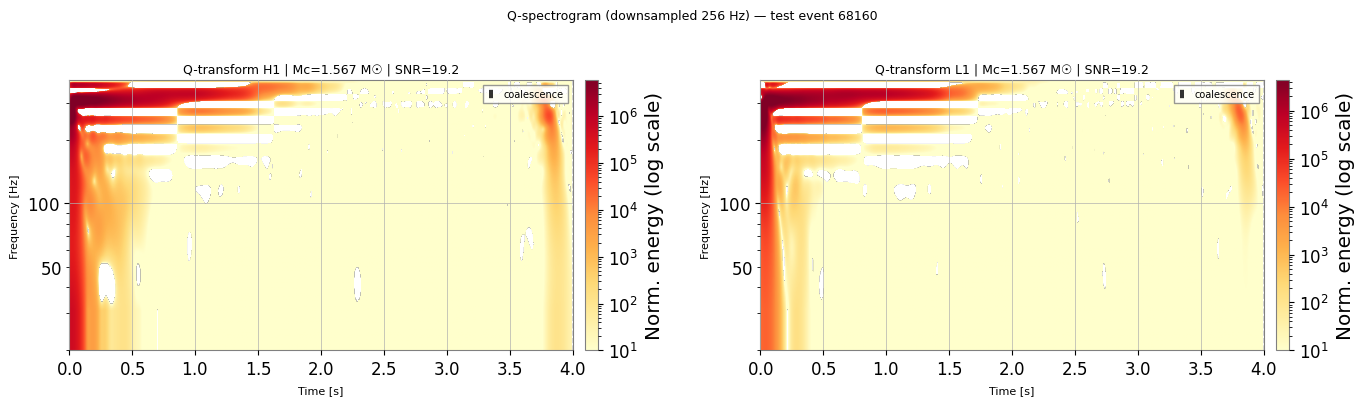

--------------------------------------------------


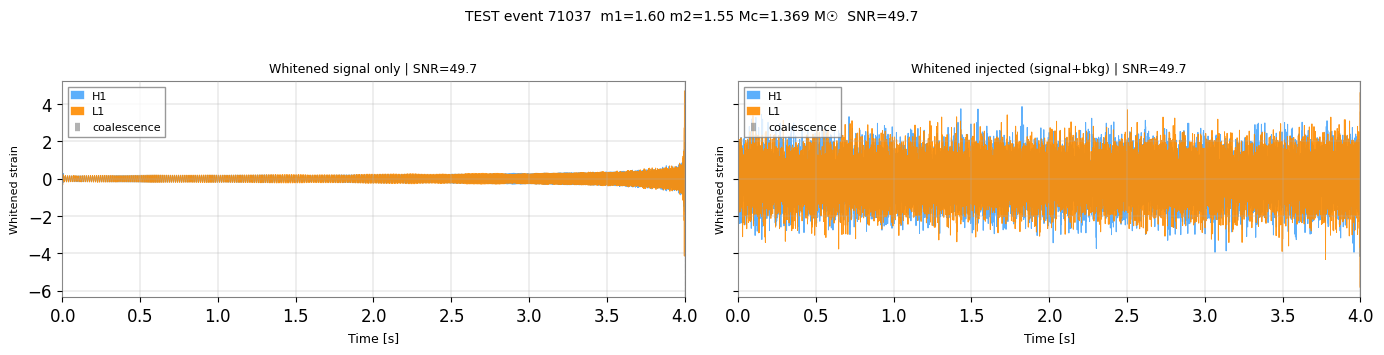

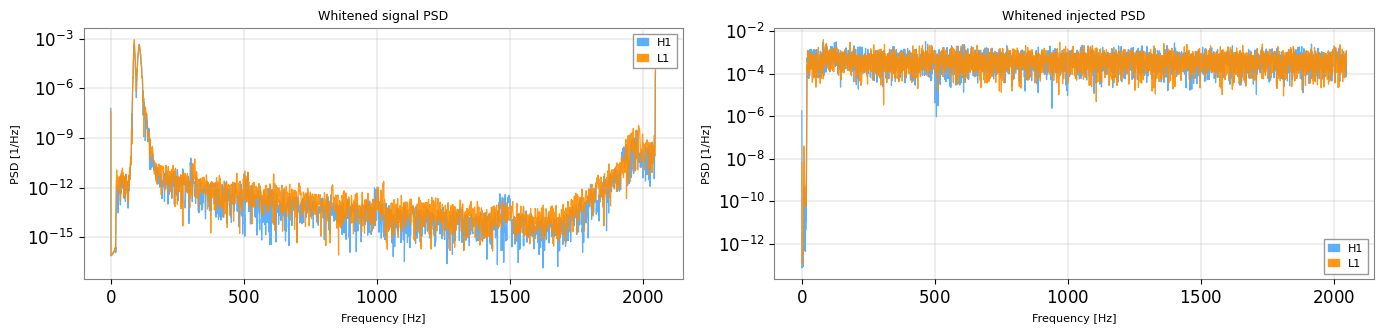

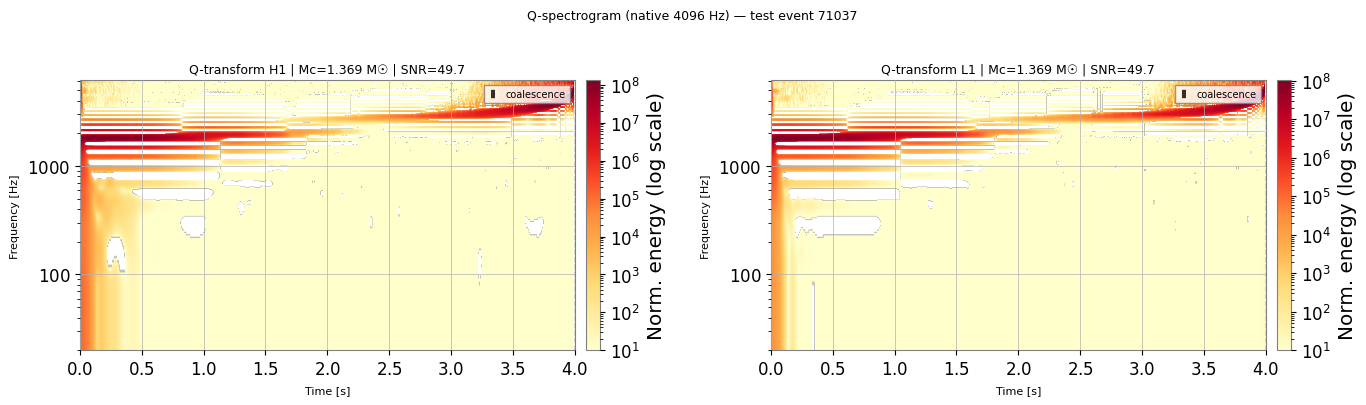

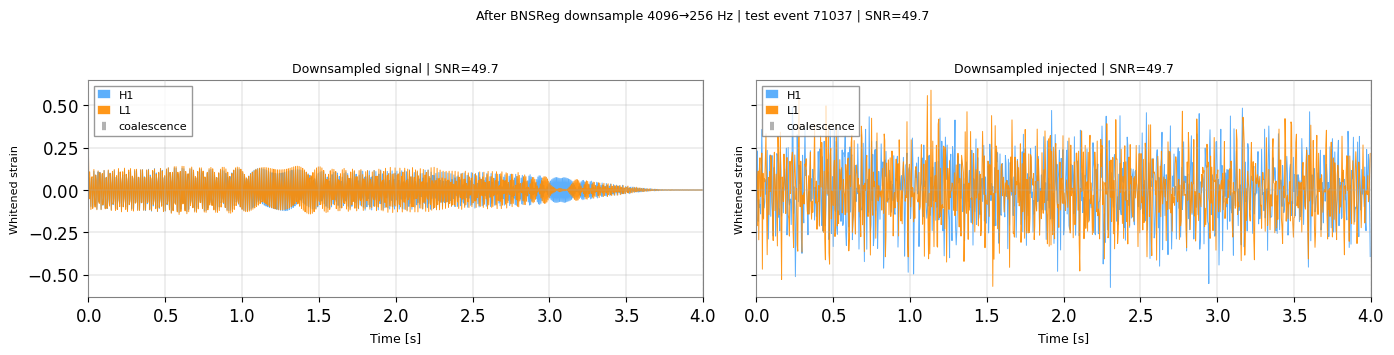

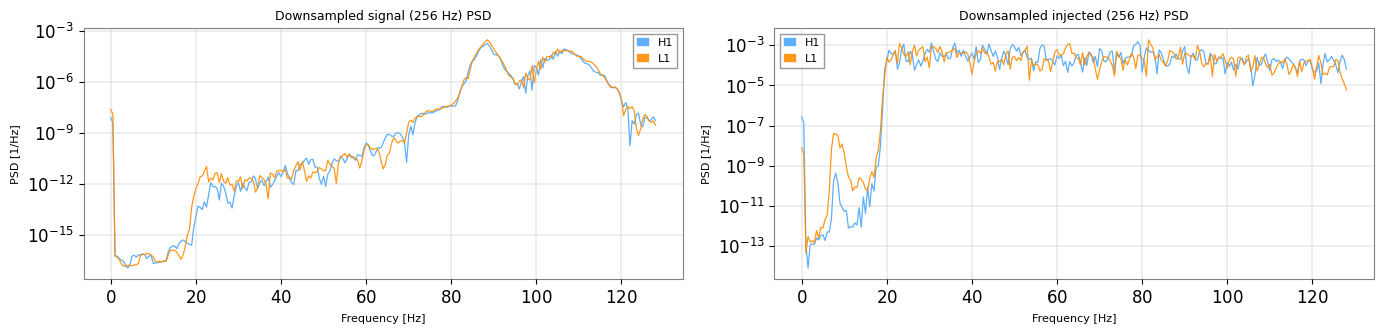

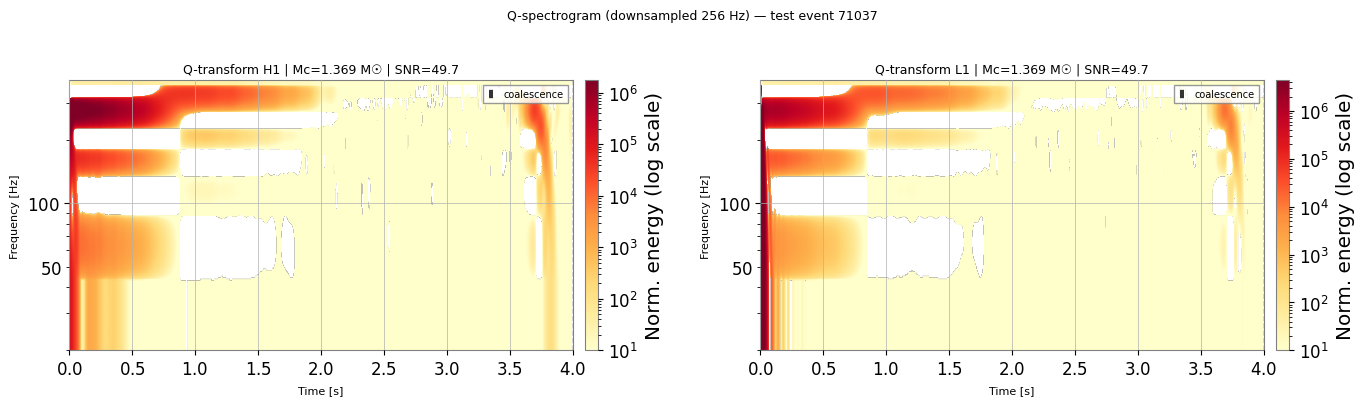

--------------------------------------------------


In [ ]:
sanity_check_split('test', TEST_H5, TEST_CFG, seed=SEED + 2)

---
## Population SNR distributions across all splits

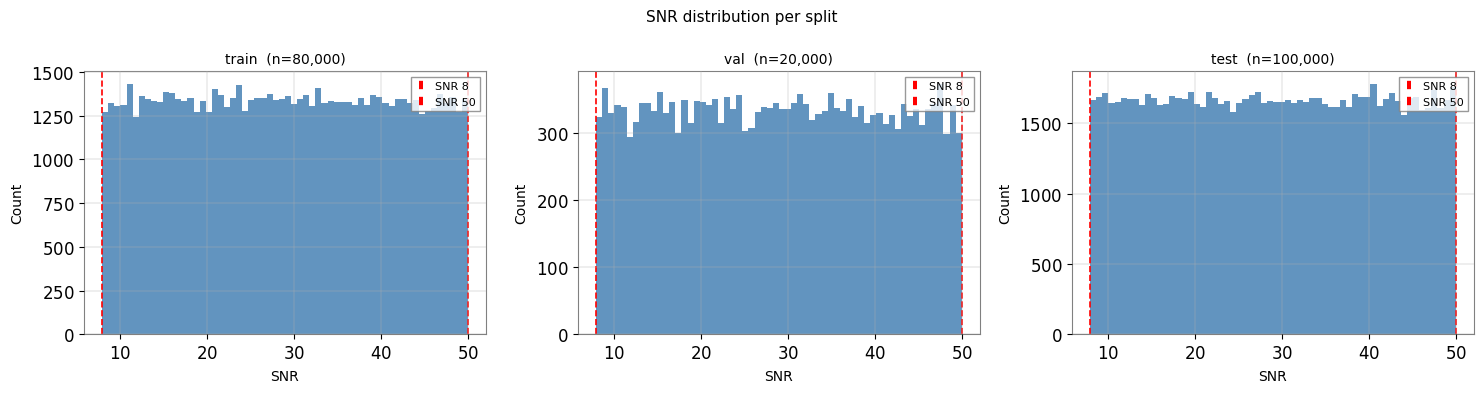

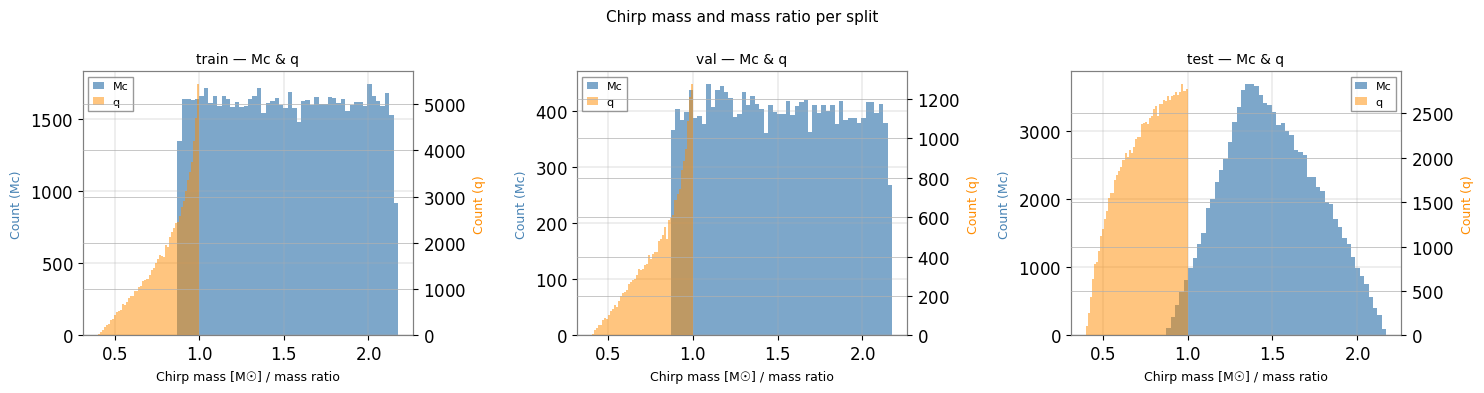

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)

for ax, (split, h5, _) in zip(axes, SPLITS):
    with h5py.File(h5, 'r') as f:
        snrs  = f['snr'][:]
        m1    = f['mass_1'][:]
        m2    = f['mass_2'][:]
        chirp = f['chirp_mass'][:]
        inv_s = f['inv_snr'][:]

    ax.hist(snrs, bins=60, color='steelblue', edgecolor='none', alpha=0.85)
    ax.axvline(8,  color='red', lw=1.2, ls='--', label='SNR 8')
    ax.axvline(50, color='red', lw=1.2, ls='--', label='SNR 50')
    ax.set_xlabel('SNR', fontsize=10)
    ax.set_ylabel('Count', fontsize=10)
    ax.set_title(f'{split}  (n={len(snrs):,})', fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(True, lw=0.3)

plt.suptitle('SNR distribution per split', fontsize=11)
plt.tight_layout()
plt.show()

# ── Chirp mass and mass ratio ─────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex='col')
for col, (split, h5, _) in enumerate(SPLITS):
    with h5py.File(h5, 'r') as f:
        chirp = f['chirp_mass'][:]
        mrat  = f['mass_ratio'][:]

    ax_top = axes[0, col]
    ax_bot = axes[1, col]

    ax_top.hist(chirp, bins=50, color='steelblue', alpha=0.7)
    ax_top.set_xlabel('Chirp mass [M☉]', fontsize=9)
    ax_top.set_ylabel('Count (Mc)', fontsize=9, color='steelblue')
    ax_top.set_title(f'{split} — Mc', fontsize=10)
    ax_top.grid(True, lw=0.3)

    ax_bot.hist(mrat, bins=50, color='darkorange', alpha=0.7)
    ax_bot.set_xlabel('Mass ratio q', fontsize=9)
    ax_bot.set_ylabel('Count (q)', fontsize=9, color='darkorange')
    ax_bot.set_title(f'{split} — q', fontsize=10)
    ax_bot.grid(True, lw=0.3)

plt.suptitle('Chirp mass and mass ratio per split', fontsize=11)
plt.tight_layout()
plt.show()